# 04 — Model training and evaluation

## Objective

Compare interpretable and tree-based classifiers using a reproducible train/test split. Preprocessing is fitted on the training partition only to avoid data leakage.

**Primary metric:** ROC-AUC. **Secondary metric:** average precision, which is informative for the imbalanced target.


## Business lens

### Decision supported

The model is designed to **rank applicants by estimated default risk**. It does not make a final lending decision: business policy converts risk estimates into approval, referral, pricing, or decline actions.

| KPI | Why it matters to the business | Use in this notebook |
| --- | --- | --- |
| ROC-AUC | Measures how well the model separates higher- and lower-risk applicants. | Primary model-selection metric. |
| Average precision | Focuses on identifying defaults in an imbalanced portfolio. | Secondary model-selection metric. |
| Approval rate | Indicates the volume retained under a chosen risk threshold. | Threshold trade-off analysis. |
| Default capture rate | Indicates how many observed defaults are flagged as high risk. | Threshold trade-off analysis. |

> Higher AUC does not automatically mean a better lending policy. The final threshold depends on expected loss, growth targets, affordability, fairness, and regulatory obligations.


In [1]:
import json

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.ensemble import GradientBoostingClassifier, HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, roc_auc_score, RocCurveDisplay
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / "data"
RAW_DATA_DIR = DATA_DIR / "Raw"
PROCESSED_DATA_DIR = DATA_DIR / "Processed"
REPORTS_DIR = PROJECT_ROOT / "reports"
MODELS_DIR = PROJECT_ROOT / "models"

RANDOM_STATE = 42
TEST_SIZE = 0.25

train = pd.read_csv(PROCESSED_DATA_DIR / "train_feature_engineered.csv")
target = train["TARGET"]
features = train.select_dtypes(include="number").drop(columns=["TARGET", "SK_ID_CURR"], errors="ignore")
features = features.replace([np.inf, -np.inf], np.nan).dropna(axis=1, how="all")

X_train, X_test, y_train, y_test = train_test_split(
    features, target, test_size=TEST_SIZE, stratify=target, random_state=RANDOM_STATE
)
print(f"Training rows: {len(X_train):,} | Test rows: {len(X_test):,} | Features: {X_train.shape[1]}")


Training rows: 230,633 | Test rows: 76,878 | Features: 116


## Candidate models

Each candidate receives its own preprocessing pipeline. Imputation and scaling are therefore learned only from the training partition.


In [2]:
def tree_pipeline(estimator):
    return Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", estimator),
    ])


models = {
    "Logistic Regression": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=1_000, class_weight="balanced", random_state=RANDOM_STATE)),
    ]),
    "Random Forest": tree_pipeline(
        RandomForestClassifier(
            n_estimators=300, max_depth=12, class_weight="balanced", n_jobs=-1, random_state=RANDOM_STATE
        )
    ),
    "Gradient Boosting": tree_pipeline(
        GradientBoostingClassifier(n_estimators=300, learning_rate=0.05, max_depth=3, random_state=RANDOM_STATE)
    ),
    "HistGradientBoosting": tree_pipeline(
        HistGradientBoostingClassifier(learning_rate=0.05, max_depth=6, max_iter=300, random_state=RANDOM_STATE)
    ),
}


In [3]:
results = []
fitted_models = {}

for name, pipeline in models.items():
    pipeline.fit(X_train, y_train)
    probabilities = pipeline.predict_proba(X_test)[:, 1]
    fitted_models[name] = pipeline
    results.append(
        {
            "model": name,
            "roc_auc": roc_auc_score(y_test, probabilities),
            "average_precision": average_precision_score(y_test, probabilities),
        }
    )

results = pd.DataFrame(results).sort_values("roc_auc", ascending=False).reset_index(drop=True)
results


,model,roc_auc,average_precision
0,HistGradientBoosting,0.763023,0.249777
1,Gradient Boosting,0.759006,0.245764
2,Logistic Regression,0.742758,0.221893
3,Random Forest,0.735427,0.213129


## Discrimination and threshold trade-offs

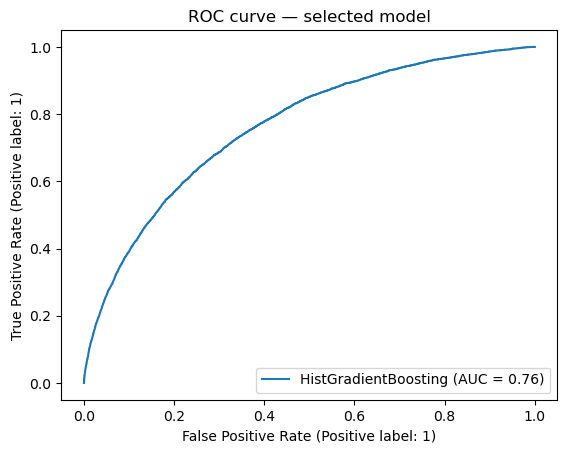

,threshold,approval_rate,default_capture_rate
0,0.05,0.469445,0.852562
1,0.10,0.745805,0.601354
2,0.15,0.861326,0.421366
3,0.20,0.921421,0.288592
4,0.25,0.953706,0.197873
5,0.30,0.972658,0.132775
6,0.35,0.983793,0.088141
7,0.40,0.990843,0.054463
8,0.45,0.995252,0.033033
9,0.50,0.997490,0.019497


In [4]:
best_model_name = results.loc[0, "model"]
best_pipeline = fitted_models[best_model_name]
best_probabilities = best_pipeline.predict_proba(X_test)[:, 1]

RocCurveDisplay.from_predictions(y_test, best_probabilities, name=best_model_name)
plt.title("ROC curve — selected model")
plt.show()

thresholds = np.arange(0.05, 1.00, 0.05)
threshold_analysis = pd.DataFrame({"threshold": thresholds})
threshold_analysis["approval_rate"] = [float((best_probabilities < threshold).mean()) for threshold in thresholds]
threshold_analysis["default_capture_rate"] = [
    float(((best_probabilities >= threshold) & (y_test.to_numpy() == 1)).sum() / y_test.sum())
    for threshold in thresholds
]
threshold_analysis


The threshold analysis is a decision-policy input, not a production approval rule. A real threshold must be set using expected loss, affordability, fairness, regulatory requirements, and portfolio strategy.


In [5]:
MODELS_DIR.mkdir(parents=True, exist_ok=True)

joblib.dump(best_pipeline, MODELS_DIR / "best_model.joblib")
metadata = {
    "best_model": best_model_name,
    "metrics": results.to_dict(orient="records"),
    "feature_columns": list(features.columns),
    "random_state": RANDOM_STATE,
    "test_size": TEST_SIZE,
}
(MODELS_DIR / "best_model_metadata.json").write_text(json.dumps(metadata, indent=2), encoding="utf-8")

print(f"Saved {best_model_name} and its metadata to {MODELS_DIR}.")


Saved HistGradientBoosting and its metadata to C:\Users\Tambo\Documents\Git\frip\models.


## Next step

Run `05_explainability.ipynb` after this notebook. It loads this exact saved pipeline, so model interpretation and the executive report refer to the same experiment.


## Model governance hand-off

The notebook saves the selected pipeline, feature list, metrics, split configuration, and random seed. This creates a reproducible experiment record for explainability, executive reporting, future validation, and model-challenge review.
